In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

import os

os.makedirs("../reports/performance_charts", exist_ok=True)

In [9]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_cleaned.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_cleaned.csv"
)

nifty50 = pd.read_csv(
    "../data/raw/NIFTY 50-05-06-2025-to-05-06-2026.csv"
)

nifty100 = pd.read_csv(
    "../data/raw/NIFTY 100-05-06-2025-to-05-06-2026.csv"
)

print(nav.shape)
print(performance.shape)

(46000, 3)
(40, 19)


In [10]:
nav["date"] = pd.to_datetime(nav["date"])

nifty50.columns = nifty50.columns.str.strip()
nifty100.columns = nifty100.columns.str.strip()

nifty50["Date"] = pd.to_datetime(
    nifty50["Date"],
    format="%d-%b-%Y"
)

nifty100["Date"] = pd.to_datetime(
    nifty100["Date"],
    format="%d-%b-%Y"
)

print(nav.shape)
print(performance.shape)
print(nifty50.shape)
print(nifty100.shape)

(46000, 3)
(40, 19)
(247, 7)
(247, 7)


In [6]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


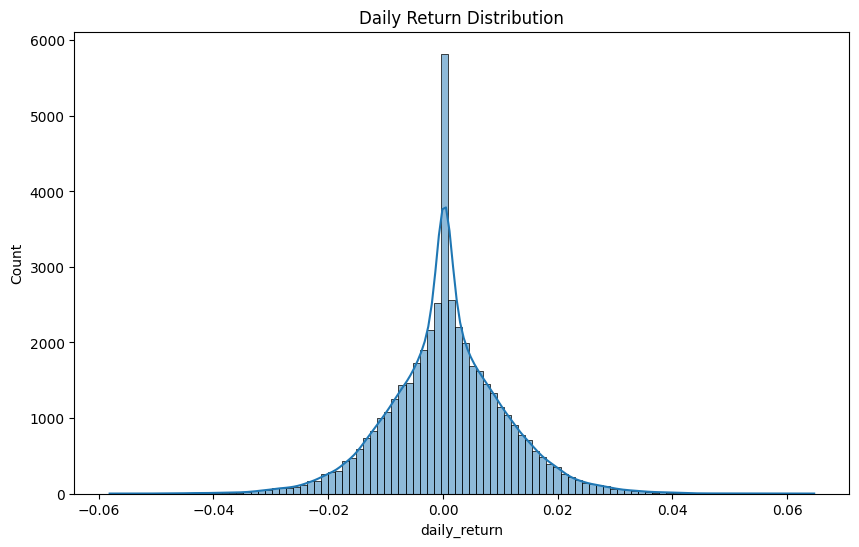

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Daily Return Distribution")

plt.savefig(
    "../reports/performance_charts/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = df.iloc[0]["nav"]
    end_nav = df.iloc[-1]["nav"]

    years = (
        (df.iloc[-1]["date"] -
         df.iloc[0]["date"]).days
    ) / 365.25

    cagr = (
        (end_nav / start_nav)
        ** (1 / years)
    ) - 1

    cagr_results.append(
        [fund, cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026371
1,100025,0.044582
2,100033,0.301232
3,101206,0.235384
4,101207,0.079388


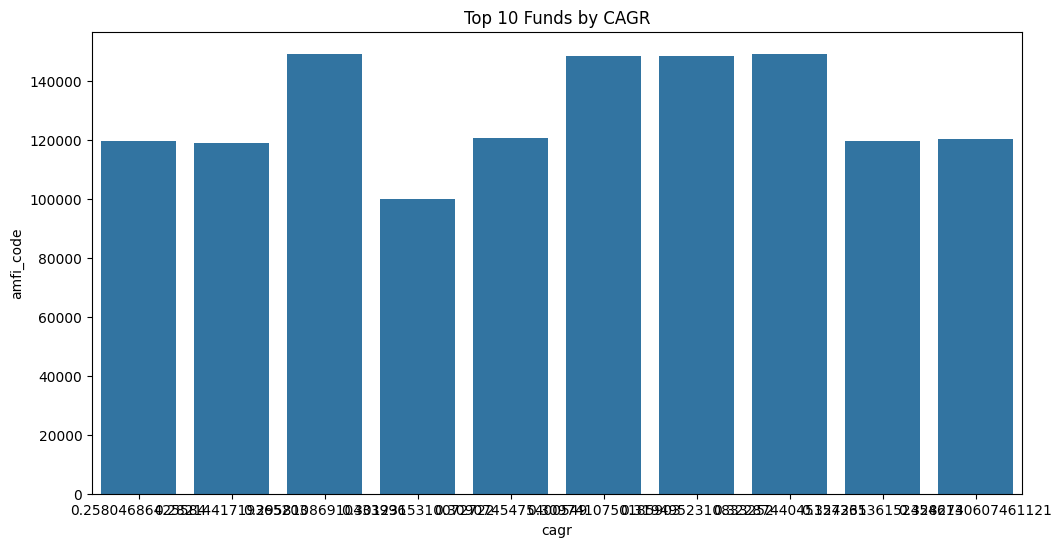

In [11]:
top10 = (
    cagr_df
    .sort_values(
        "cagr",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="cagr",
    y="amfi_code"
)

plt.title("Top 10 Funds by CAGR")

plt.savefig(
    "../reports/performance_charts/top10_cagr.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The best-performing schemes generated significantly higher CAGR values than their peers, demonstrating the importance of fund selection.

In [13]:
RF = 0.065

sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_nav = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    if "daily_return" not in fund_nav.columns:
        fund_nav = fund_nav.assign(
            daily_return=fund_nav["nav"].pct_change()
        )

    ret = fund_nav["daily_return"].dropna()

    annual_return = (
        ret.mean()*252
    )

    annual_vol = (
        ret.std()*np.sqrt(252)
    )

    sharpe = (
        annual_return - RF
    ) / annual_vol

    sharpe_results.append(
        [fund,sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe"
    ]
)

sharpe_df.head()

,amfi_code,sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


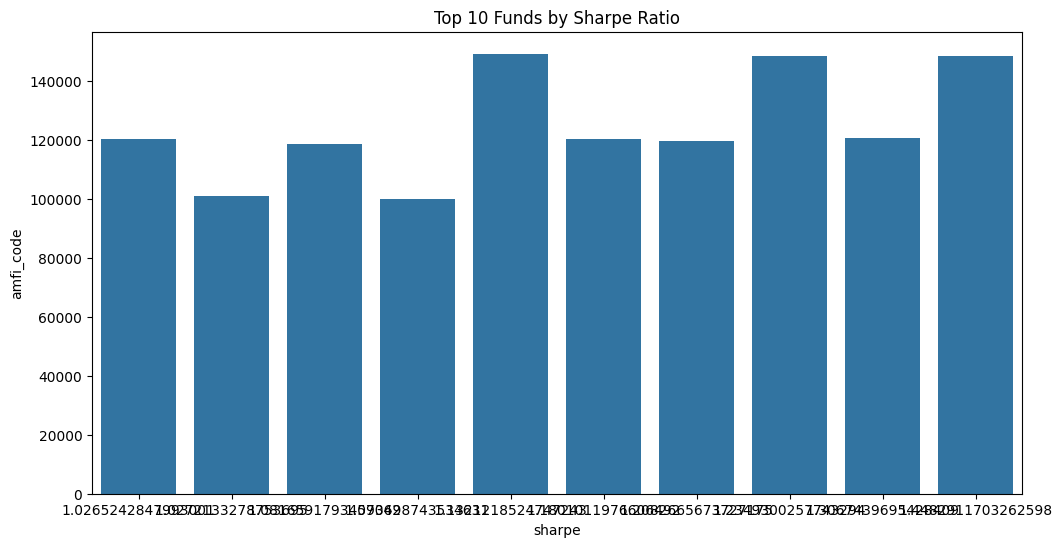

In [14]:
top_sharpe = (
    sharpe_df
    .sort_values(
        "sharpe",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.savefig(
    "../reports/performance_charts/top_sharpe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Funds with higher Sharpe Ratios delivered better risk-adjusted returns compared to other schemes.

In [15]:
print(cagr_df.head())

print(sharpe_df.head())

   amfi_code      cagr
0     100016  0.026371
1     100025  0.044582
2     100033  0.301232
3     101206  0.235384
4     101207  0.079388
   amfi_code    sharpe
0     100016 -0.201517
1     100025 -0.567095
2     100033  1.093699
3     101206  1.027213
4     101207  0.162661


In [17]:
sortino_results = []

for fund in nav["amfi_code"].unique():

    fund_nav = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")
    
    ret = fund_nav["nav"].pct_change().dropna()

    downside = ret[ret < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = (
        ret.mean() * 252
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append(
        [fund, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino"
    ]
)

sortino_df.head()

,amfi_code,sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


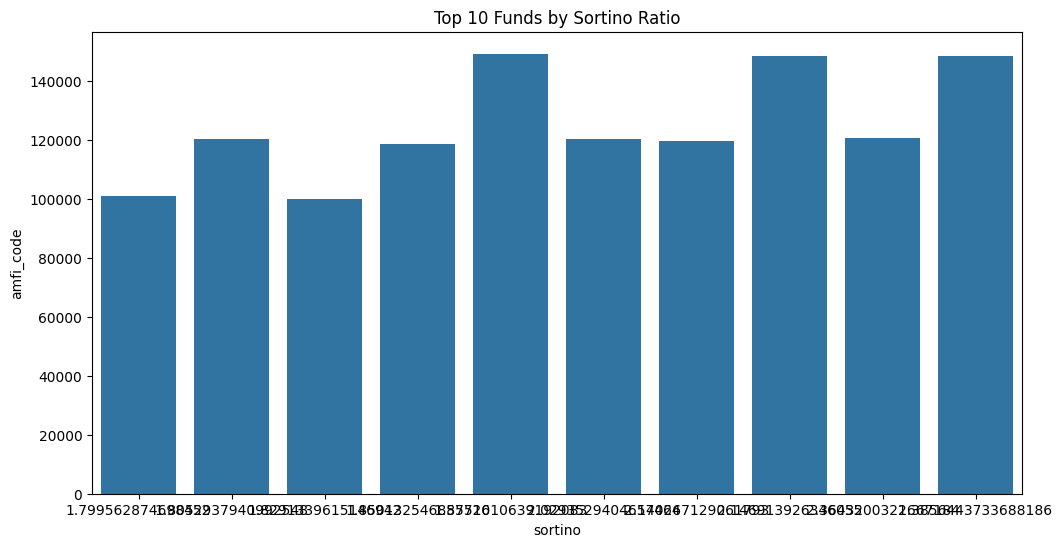

In [18]:
top_sortino = (
    sortino_df
    .sort_values(
        "sortino",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino",
    y="amfi_code"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.savefig(
    "../reports/performance_charts/top_sortino.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
nifty100 = nifty100.rename(
    columns={
        "Date":"date"
    }
)

nifty100["benchmark_return"] = (
    nifty100["Close"]
    .pct_change()
)

In [21]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ][["date", "nav"]].copy()
    
    fund_df["daily_return"] = (
        fund_df["nav"].pct_change()
    )

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    slope, intercept, r, p, se = (
        linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.023344,-0.139056
1,100025,0.044394,-0.009748
2,100033,0.384559,0.029508
3,101206,0.341845,0.010459
4,101207,-0.258697,0.084368


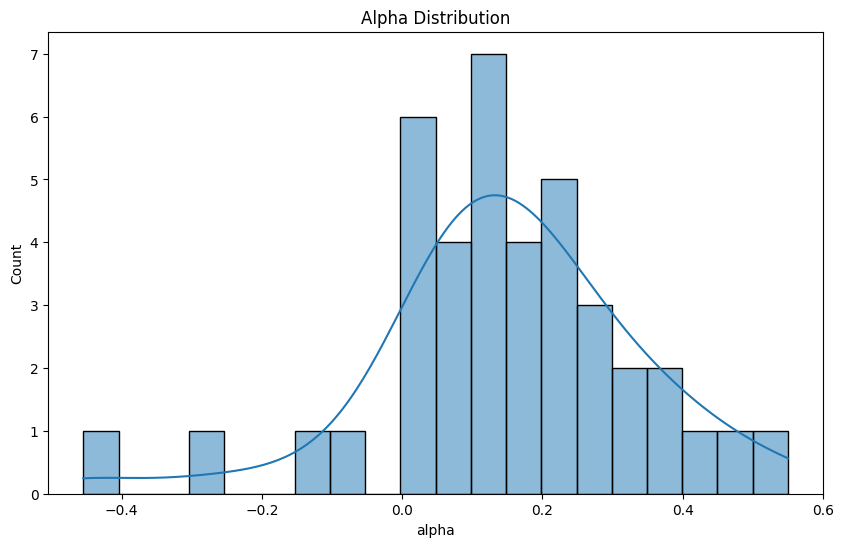

In [22]:
plt.figure(figsize=(10,6))

sns.histplot(
    alpha_beta_df["alpha"],
    bins=20,
    kde=True
)

plt.title("Alpha Distribution")

plt.savefig(
    "../reports/performance_charts/alpha_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

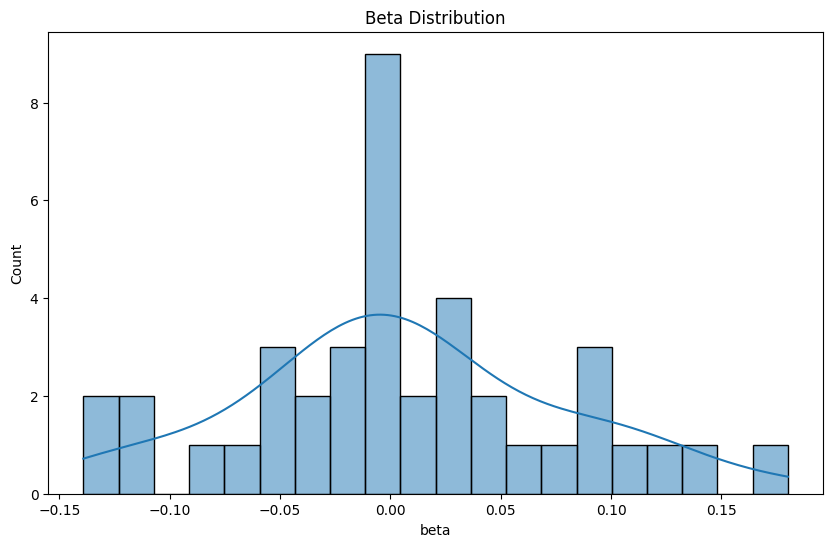

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    alpha_beta_df["beta"],
    bins=20,
    kde=True
)

plt.title("Beta Distribution")

plt.savefig(
    "../reports/performance_charts/beta_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
dd_results = []

for fund in nav["amfi_code"].unique():

    df = nav[
        nav["amfi_code"] == fund
    ].copy()

    running_max = (
        df["nav"]
        .cummax()
    )

    drawdown = (
        df["nav"]
        / running_max
    ) - 1

    max_dd = drawdown.min()

    dd_results.append(
        [fund, max_dd]
    )

dd_df = pd.DataFrame(
    dd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

dd_df.head()


,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


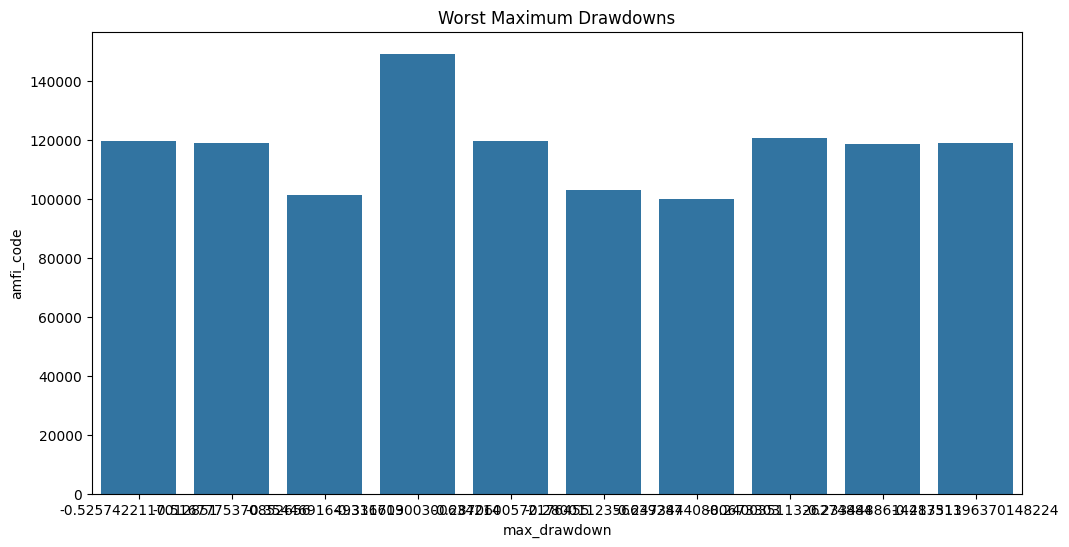

In [25]:
worst_dd = (
    dd_df
    .sort_values(
        "max_drawdown"
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_dd,
    x="max_drawdown",
    y="amfi_code"
)

plt.title("Worst Maximum Drawdowns")

plt.savefig(
    "../reports/performance_charts/max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
print(sortino_df.head())

print(alpha_beta_df.head())

print(dd_df.head())

   amfi_code   sortino
0     100016 -0.351047
1     100025 -0.941821
2     100033  1.829134
3     101206  1.799563
4     101207  0.276644
   amfi_code     alpha      beta
0     100016  0.023344 -0.139056
1     100025  0.044394 -0.009748
2     100033  0.384559  0.029508
3     101206  0.341845  0.010459
4     101207 -0.258697  0.084368
   amfi_code  max_drawdown
0     100016     -0.247344
1     100025     -0.043083
2     100033     -0.162172
3     101206     -0.112916
4     101207     -0.354469


In [28]:
tracking_error = []

for fund in nav["amfi_code"].unique():

    fund_df = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")[["date","nav"]].copy()
    fund_df["daily_return"] = fund_df["nav"].pct_change()

    merged = pd.merge(
        fund_df,
        nifty100[
            ["date","benchmark_return"]
        ],
        on="date"
    ).dropna()

    te = (
        (
            merged["daily_return"]
            -
            merged["benchmark_return"]
        ).std()
    ) * np.sqrt(252)

    tracking_error.append(
        [fund, te]
    )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "tracking_error"
    ]
)

tracking_error_df.head()

,amfi_code,tracking_error
0,100016,0.212955
1,100025,0.141395
2,100033,0.219135
3,101206,0.194104
4,101207,0.276596


In [29]:
scorecard = (
    performance[
        [
            "amfi_code",
            "return_3yr_pct",
            "expense_ratio_pct"
        ]
    ]
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(dd_df)
)

In [30]:
scorecard["return_rank"] = (
    scorecard["return_3yr_pct"]
    .rank(pct=True)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe"]
    .rank(pct=True)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(pct=True)
)

scorecard["expense_rank"] = (
    (-scorecard["expense_ratio_pct"])
    .rank(pct=True)
)

scorecard["drawdown_rank"] = (
    (-scorecard["max_drawdown"])
    .rank(pct=True)
)

In [31]:
scorecard["fund_score"] = (

      scorecard["return_rank"] * 30

    + scorecard["sharpe_rank"] * 25

    + scorecard["alpha_rank"] * 20

    + scorecard["expense_rank"] * 15

    + scorecard["drawdown_rank"] * 10

)

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head()

,amfi_code,return_3yr_pct,expense_ratio_pct,sharpe,alpha,beta,max_drawdown,return_rank,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,fund_score
2,119598,23.39,1.43,0.945308,0.483730,0.180133,-0.287060,1.000,0.675,0.975,0.5000,0.900,82.8750
12,120505,18.08,1.36,1.180101,0.304563,0.024971,-0.181885,0.825,0.900,0.850,0.6500,0.625,80.2500
39,149324,20.08,1.52,0.949796,0.549919,0.009959,-0.311719,0.875,0.700,1.000,0.3625,0.925,78.4375
7,100033,16.58,1.38,1.093699,0.384559,0.029508,-0.162172,0.775,0.850,0.900,0.6000,0.500,76.5000
22,120843,15.65,1.45,1.306744,0.200257,-0.109517,-0.129740,0.750,0.975,0.650,0.4750,0.325,70.2500


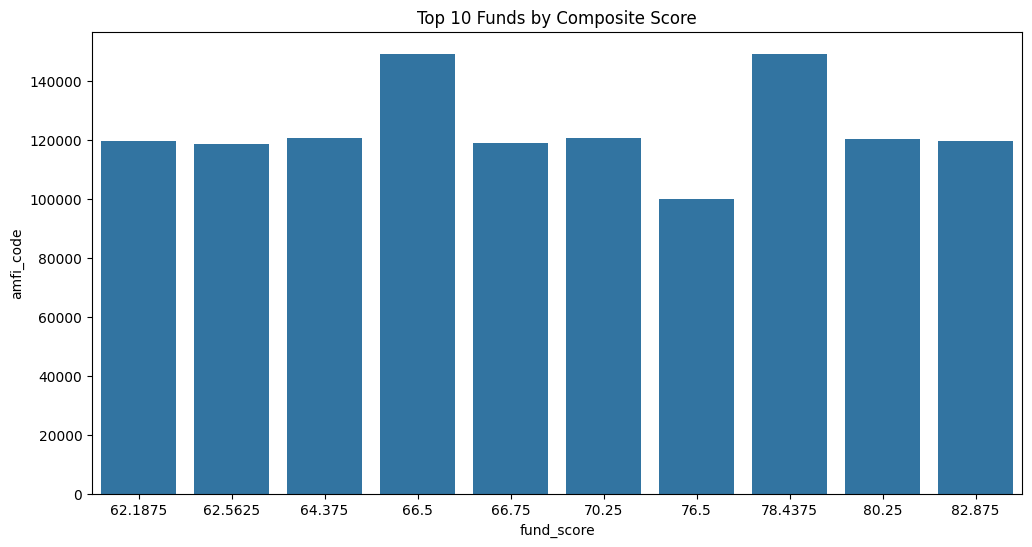

In [32]:
top10_score = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_score,
    x="fund_score",
    y="amfi_code"
)

plt.title("Top 10 Funds by Composite Score")

plt.savefig(
    "../reports/performance_charts/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
#Top 5 Funds vs NIFTY 50 and NIFTY 100
top5 = (
    scorecard
    .head(5)
    ["amfi_code"]
    .tolist()
)

top5

[119598, 120505, 149324, 100033, 120843]

In [34]:
nifty50 = nifty50.sort_values("Date")
nifty100 = nifty100.sort_values("date")

nifty50["normalized"] = (
    nifty50["Close"]
    /
    nifty50["Close"].iloc[0]
) * 100

nifty100["normalized"] = (
    nifty100["Close"]
    /
    nifty100["Close"].iloc[0]
) * 100

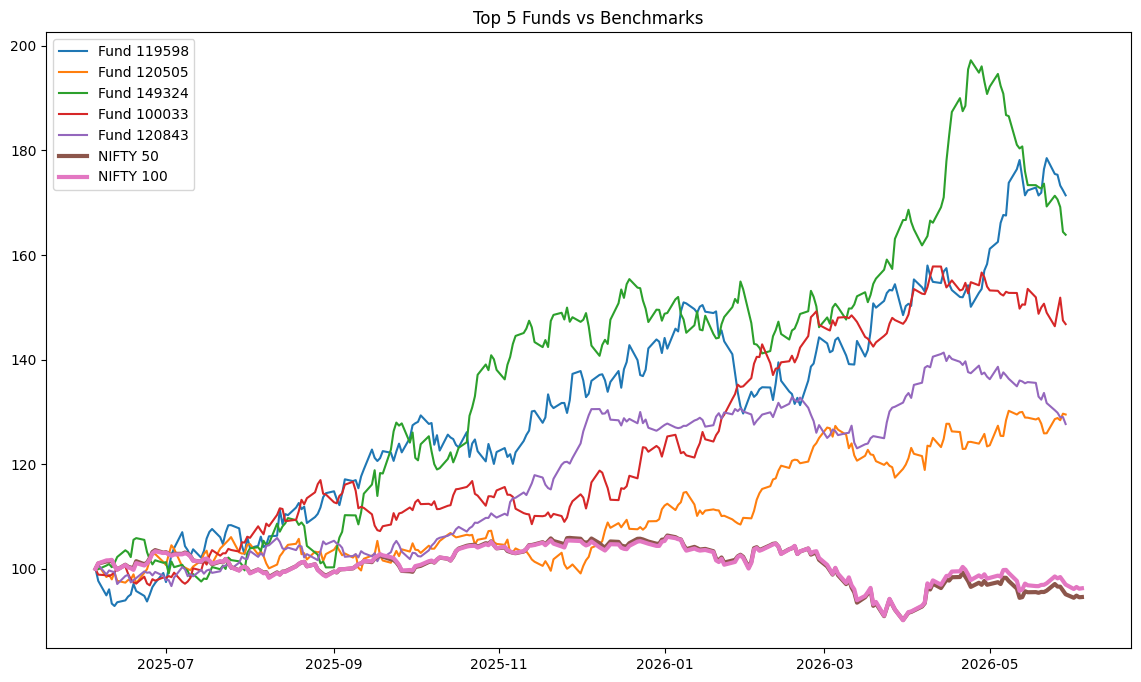

In [35]:
plt.figure(figsize=(14,8))

for fund in top5:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp = temp[
        temp["date"] >= nifty100["date"].min()
    ]

    temp["normalized"] = (
        temp["nav"]
        /
        temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {fund}"
    )

plt.plot(
    nifty50["Date"],
    nifty50["normalized"],
    linewidth=3,
    label="NIFTY 50"
)

plt.plot(
    nifty100["date"],
    nifty100["normalized"],
    linewidth=3,
    label="NIFTY 100"
)

plt.legend()

plt.title(
    "Top 5 Funds vs Benchmarks"
)

plt.savefig(
    "../reports/performance_charts/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

In [37]:
import os

print(os.listdir("../reports"))

print(
    os.listdir(
        "../reports/performance_charts"
    )
)

['alpha_beta.csv', 'charts', 'data_dictionary.md', 'day1_data_quality_report.md', 'day2_summary.md', 'fund_scorecard.csv', 'performance_charts', 'tracking_error.csv']
['alpha_distribution.png', 'benchmark_comparison.png', 'beta_distribution.png', 'daily_return_distribution.png', 'fund_scorecard.png', 'max_drawdown.png', 'top10_cagr.png', 'top_sharpe.png', 'top_sortino.png']


In [2]:
pip install scipy


  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
